In [16]:
data <- read.csv("sdg6_sanitation_pre_post.csv")
head(data)

,Country,Pre_Improved_Sanitation,Post_Improved_Sanitation,Sample_Size
,<chr>,<int>,<int>,<int>
1,Kenya,56,70,100
2,Uganda,53,69,100
3,Tanzania,61,69,100
4,Rwanda,63,75,100
5,Ethiopia,47,65,100
6,Nepal,53,67,100


In [17]:
alpha_prior <- 10
beta_prior <- 10

In [18]:
data$Post_Alpha <- alpha_prior + data$Post_Improved_Sanitation
data$Post_Beta <- beta_prior + (data$Sample_Size - data$Post_Improved_Sanitation)

In [19]:
data$Post_Alpha <- alpha_prior + data$Post_Improved_Sanitation
data$Post_Beta <- beta_prior + (data$Sample_Size - data$Post_Improved_Sanitation)

In [20]:
set.seed(42)
data$Prob_Above_70 <- sapply(1:nrow(data), function(i) {
  samples <- rbeta(10000, data$Post_Alpha[i], data$Post_Beta[i])
  mean(samples > 0.7)
})

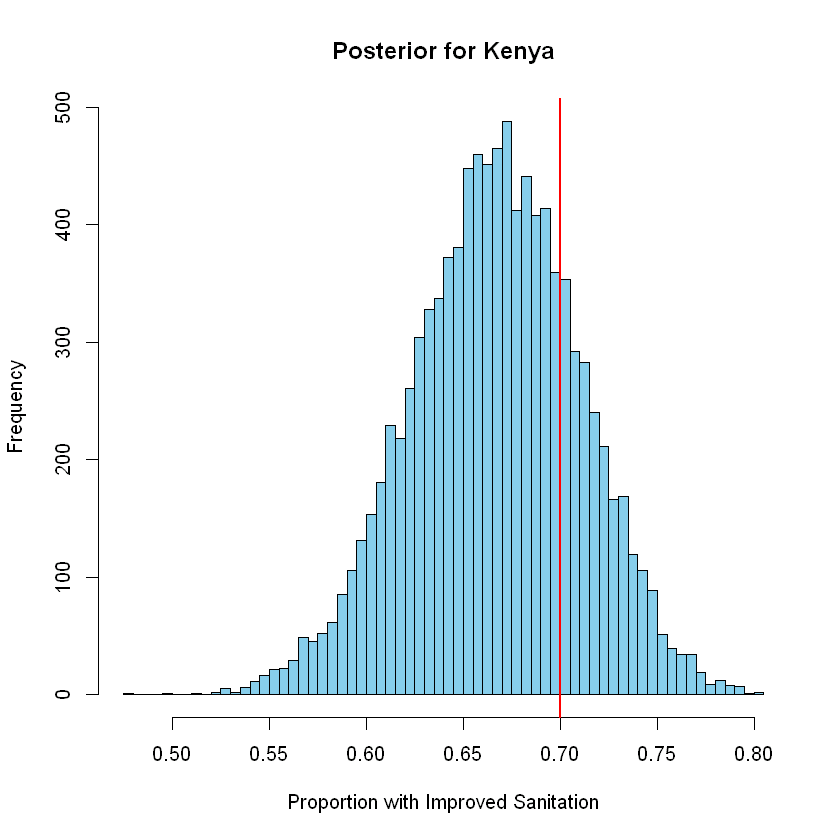

In [21]:
samples <- rbeta(10000, data$Post_Alpha[1], data$Post_Beta[1])
hist(samples, breaks = 50, col = "skyblue",
     main = paste("Posterior for", data$Country[1]),
     xlab = "Proportion with Improved Sanitation")
abline(v = 0.7, col = "red", lwd = 2)

In [22]:
summary_table <- data[c("Country", "Post_Improved_Sanitation", "Prob_Above_70")]
print(summary_table)

      Country Post_Improved_Sanitation Prob_Above_70
1       Kenya                       70        0.2248
2      Uganda                       69        0.1667
3    Tanzania                       69        0.1722
4      Rwanda                       75        0.5859
5    Ethiopia                       65        0.0387
6       Nepal                       67        0.0905
7  Bangladesh                       71        0.2881
8    Cambodia                       75        0.5925
9       Haiti                       70        0.2304
10  Guatemala                       68        0.1250


In [24]:
# Expected improvement using posterior means
# Posterior mean of a Beta(alpha, beta) = alpha / (alpha + beta)

# Post-intervention posterior (already have Post_Alpha, Post_Beta from earlier)
data$Post_Mean <- data$Post_Alpha / (data$Post_Alpha + data$Post_Beta)

# Pre-intervention posterior
data$Pre_Alpha <- alpha_prior + data$Pre_Improved_Sanitation
data$Pre_Beta  <- beta_prior  + (data$Sample_Size - data$Pre_Improved_Sanitation)
data$Pre_Mean  <- data$Pre_Alpha / (data$Pre_Alpha + data$Pre_Beta)

# Expected improvement in percentage points
data$Expected_Improvement_pp <- round((data$Post_Mean - data$Pre_Mean) * 100, 1)

# Show it
imp <- data[c("Country", "Pre_Mean", "Post_Mean", "Expected_Improvement_pp")]
imp$Pre_Mean  <- round(imp$Pre_Mean, 3)
imp$Post_Mean <- round(imp$Post_Mean, 3)
print(imp[order(-imp$Expected_Improvement_pp), ], row.names = FALSE)

    Country Pre_Mean Post_Mean Expected_Improvement_pp
   Cambodia    0.492     0.708                    21.7
   Ethiopia    0.475     0.625                    15.0
 Bangladesh    0.533     0.675                    14.2
     Uganda    0.525     0.658                    13.3
  Guatemala    0.517     0.650                    13.3
      Kenya    0.550     0.667                    11.7
      Nepal    0.525     0.642                    11.7
      Haiti    0.550     0.667                    11.7
     Rwanda    0.608     0.708                    10.0
   Tanzania    0.592     0.658                     6.7
